# HW2 Policy Gradient — Training Curves

In [5]:
import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import wandb

In [6]:
def _base_exp_name(exp_name: str) -> str:
    """Strip the '_lb' size token to get the canonical base name for color lookup."""
    parts = exp_name.split("_")
    return "_".join(p for p in parts if p != "lb")


def expand_exp_name(exp_name: str) -> str:
    """Expand abbreviations in an exp_name into a human-readable legend label."""
    parts = exp_name.split("_")
    flag_tokens = [p for p in parts if p not in ("cartpole", "lb")]
    expansions = {"rtg": "reward_to_go=True", "na": "normalize_advantages=T"}
    expanded = [expansions.get(tok, tok) for tok in flag_tokens]
    return ", ".join(expanded) if expanded else "baseline"


def build_color_map(exp_names: list[str]) -> dict[str, tuple]:
    """
    Assign a consistent tab10 color to each exp name.

    lb variants are collapsed to their base name so that e.g. cartpole and
    cartpole_lb receive the same color.
    """
    palette = plt.cm.tab10.colors
    base_names = list(dict.fromkeys(_base_exp_name(n) for n in exp_names))
    base_colors = {name: palette[i] for i, name in enumerate(base_names)}
    return {name: base_colors[_base_exp_name(name)] for name in exp_names}


def download_runs(
    project: str,
    cache_dir: Path,
    metrics: list[str],
) -> dict[str, dict]:
    """
    Download per-step metrics for every run in *project*.

    Results are cached as JSON under *cache_dir/<run_id>.json* so subsequent
    calls skip already-fetched runs.  The cache is invalidated automatically
    when *metrics* contains a key not present in the cached data.

    Returns a dict keyed by wandb run ID::

        {run_id: {"exp_name": str, "created_at": str, "data": pd.DataFrame}}
    """
    cache_dir.mkdir(parents=True, exist_ok=True)
    api = wandb.Api()
    runs = api.runs(project)

    run_data: dict[str, dict] = {}
    for run in runs:
        cache_path = cache_dir / f"{run.id}.json"
        df = None
        if cache_path.exists():
            with open(cache_path) as f:
                df = pd.DataFrame(json.load(f))
            if not all(m in df.columns for m in metrics):
                cache_path.unlink()
                df = None
        if df is None:
            rows = list(run.scan_history(keys=metrics))
            df = pd.DataFrame(rows)
            with open(cache_path, "w") as f:
                json.dump(df.to_dict(orient="list"), f)

        run_data[run.id] = {
            "exp_name": run.config.get("exp_name", ""),
            "created_at": run.created_at,
            "data": df,
        }

    return run_data


def group_runs(run_data: dict[str, dict], exp_names: list[str]) -> dict[str, pd.DataFrame]:
    """
    Filter *run_data* to the requested *exp_names*.

    When multiple runs share the same exp_name the most recent one is used and
    a warning is raised.  Returns a dict mapping exp_name → DataFrame.
    """
    groups: dict[str, pd.DataFrame] = {}
    for exp_name in exp_names:
        matches = [
            (rid, info)
            for rid, info in run_data.items()
            if info["exp_name"] == exp_name
        ]
        if not matches:
            warnings.warn(f"No runs found for exp_name '{exp_name}'")
            continue
        if len(matches) > 1:
            warnings.warn(
                f"{len(matches)} runs found for exp_name '{exp_name}' — using the most recent one."
            )
        matches.sort(key=lambda x: x[1]["created_at"], reverse=True)
        groups[exp_name] = matches[0][1]["data"]
    return groups


def make_plot(
    groups: dict[str, pd.DataFrame],
    title: str,
    y_metrics: list[str] | None = None,
    color_map: dict[str, tuple] | None = None,
    save_dir: Path | None = None,
    n_cols: int = 5,
) -> None:
    """Plot a grid of subplots, each showing a different metric vs Train_EnvstepsSoFar.

    Default layout is 2 rows × 5 cols: Train metrics on top, Eval metrics on bottom.
    If *color_map* is omitted, colors are assigned automatically from tab10
    in the order experiments appear in *groups*.  If *save_dir* is provided
    the figure is saved to *save_dir/<title>.png* (lowercased, spaces as
    underscores).
    """
    if y_metrics is None:
        y_metrics = [
            "Train_AverageReturn", "Train_StdReturn", "Train_MaxReturn", "Train_MinReturn", "Train_AverageEpLen",
            "Eval_AverageReturn", "Eval_StdReturn", "Eval_MaxReturn", "Eval_MinReturn", "Eval_AverageEpLen",
        ]

    x_metric = "Train_EnvstepsSoFar"
    palette = plt.cm.tab10.colors

    # Assign a stable color per experiment up front so it's consistent across subplots.
    if color_map is not None:
        exp_colors = {name: color_map.get(name, "gray") for name in groups}
    else:
        exp_colors = {name: palette[i % len(palette)] for i, name in enumerate(groups)}

    n_rows = math.ceil(len(y_metrics) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = [ax for row in axes for ax in row]

    for ax, y_metric in zip(axes_flat, y_metrics):
        for exp_name, df in groups.items():
            if df.empty or x_metric not in df.columns or y_metric not in df.columns:
                warnings.warn(f"No plottable data for '{exp_name}' / '{y_metric}'")
                continue
            df_sorted = df.dropna(subset=[x_metric, y_metric]).sort_values(x_metric)
            ax.plot(
                df_sorted[x_metric],
                df_sorted[y_metric],
                label=expand_exp_name(exp_name),
                color=exp_colors[exp_name],
            )
        ax.set_xlabel("Environment Steps")
        ax.set_ylabel(y_metric)
        ax.set_title(y_metric)
        ax.legend(fontsize="small")

    for ax in axes_flat[len(y_metrics):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = title.lower().replace(" ", "_") + ".png"
        fig.savefig(save_dir / filename)

    plt.show()

In [7]:
run_data = download_runs(
    project="cs285_hw2",
    cache_dir=Path("../wandb_cache"),
    metrics=[
        "Train_EnvstepsSoFar",
        "Eval_AverageReturn", "Eval_StdReturn", "Eval_MaxReturn", "Eval_MinReturn", "Eval_AverageEpLen",
        "Train_AverageReturn", "Train_StdReturn", "Train_MaxReturn", "Train_MinReturn", "Train_AverageEpLen",
    ],
)

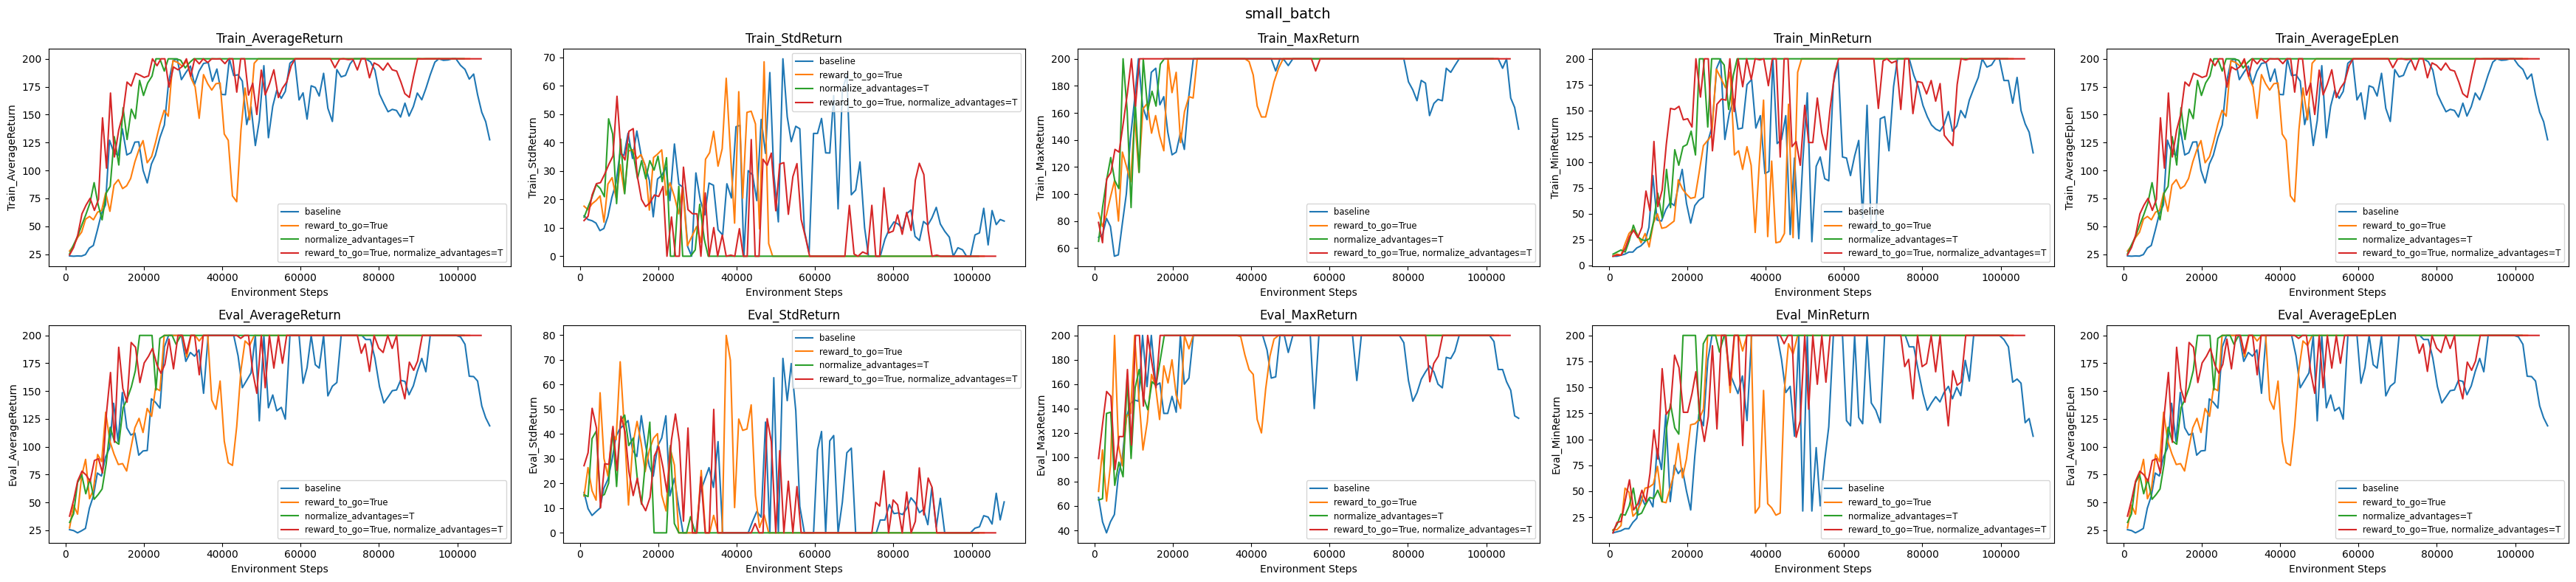

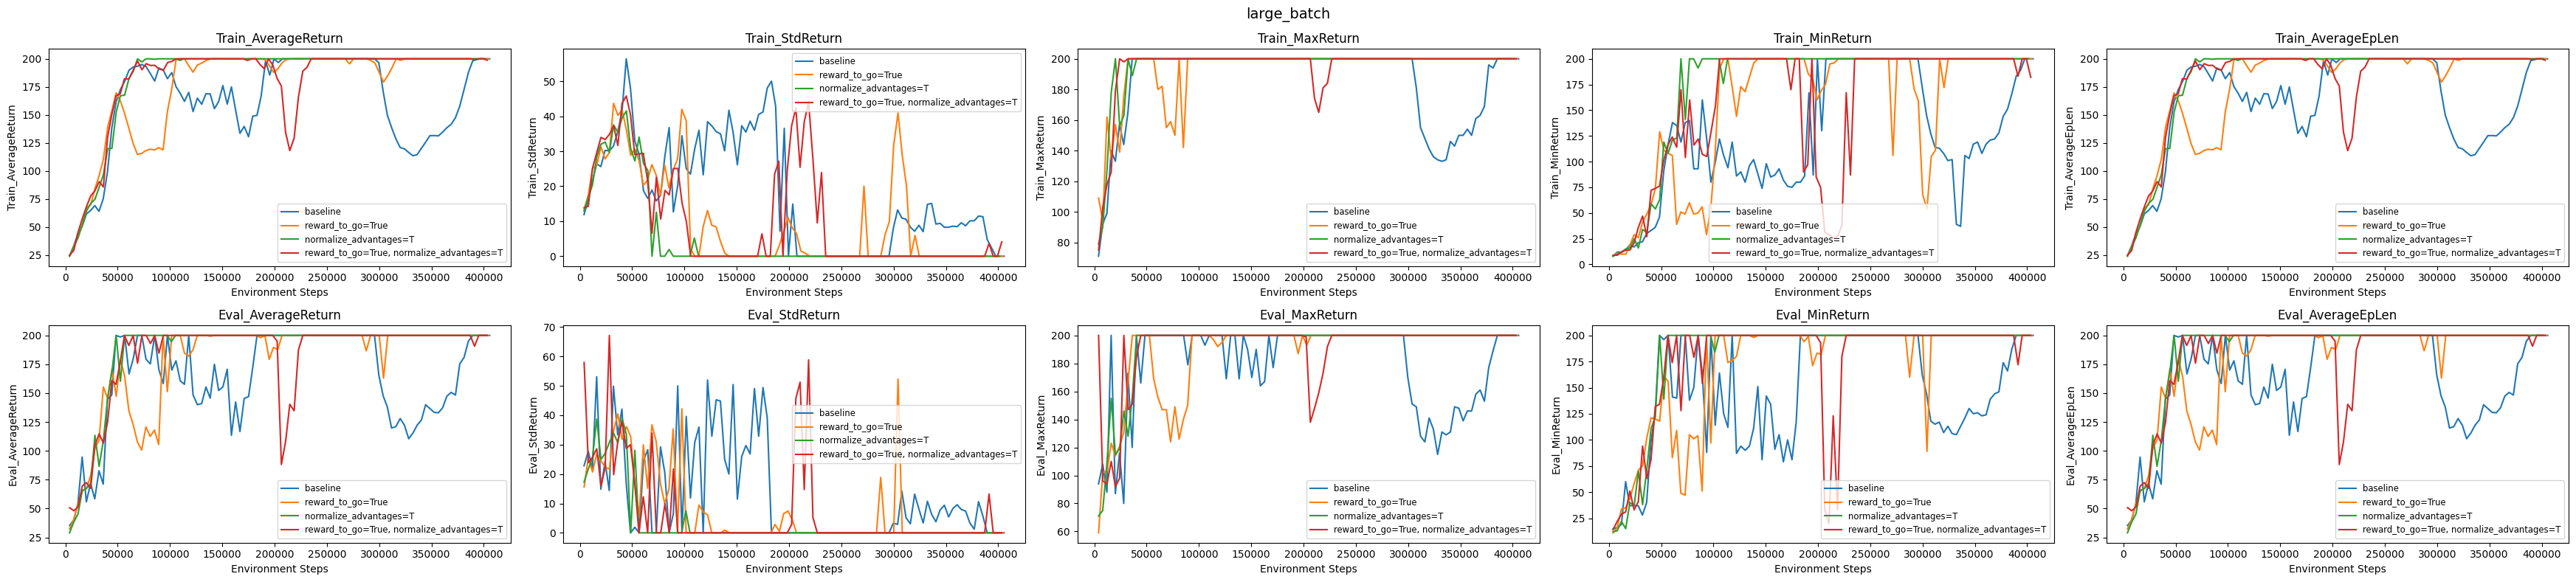

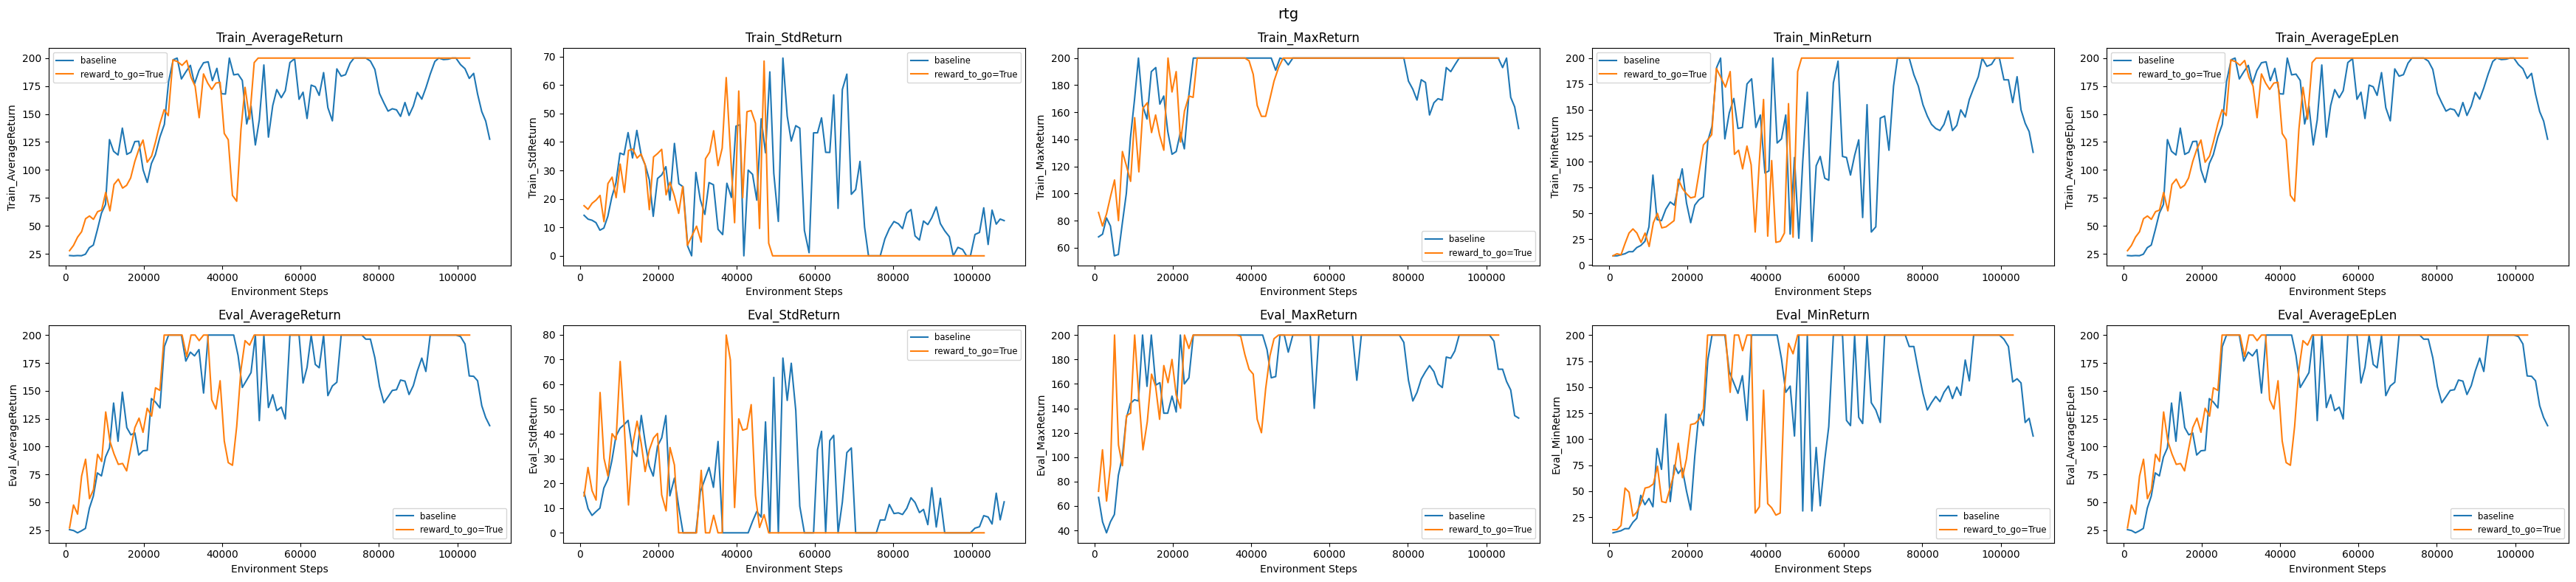

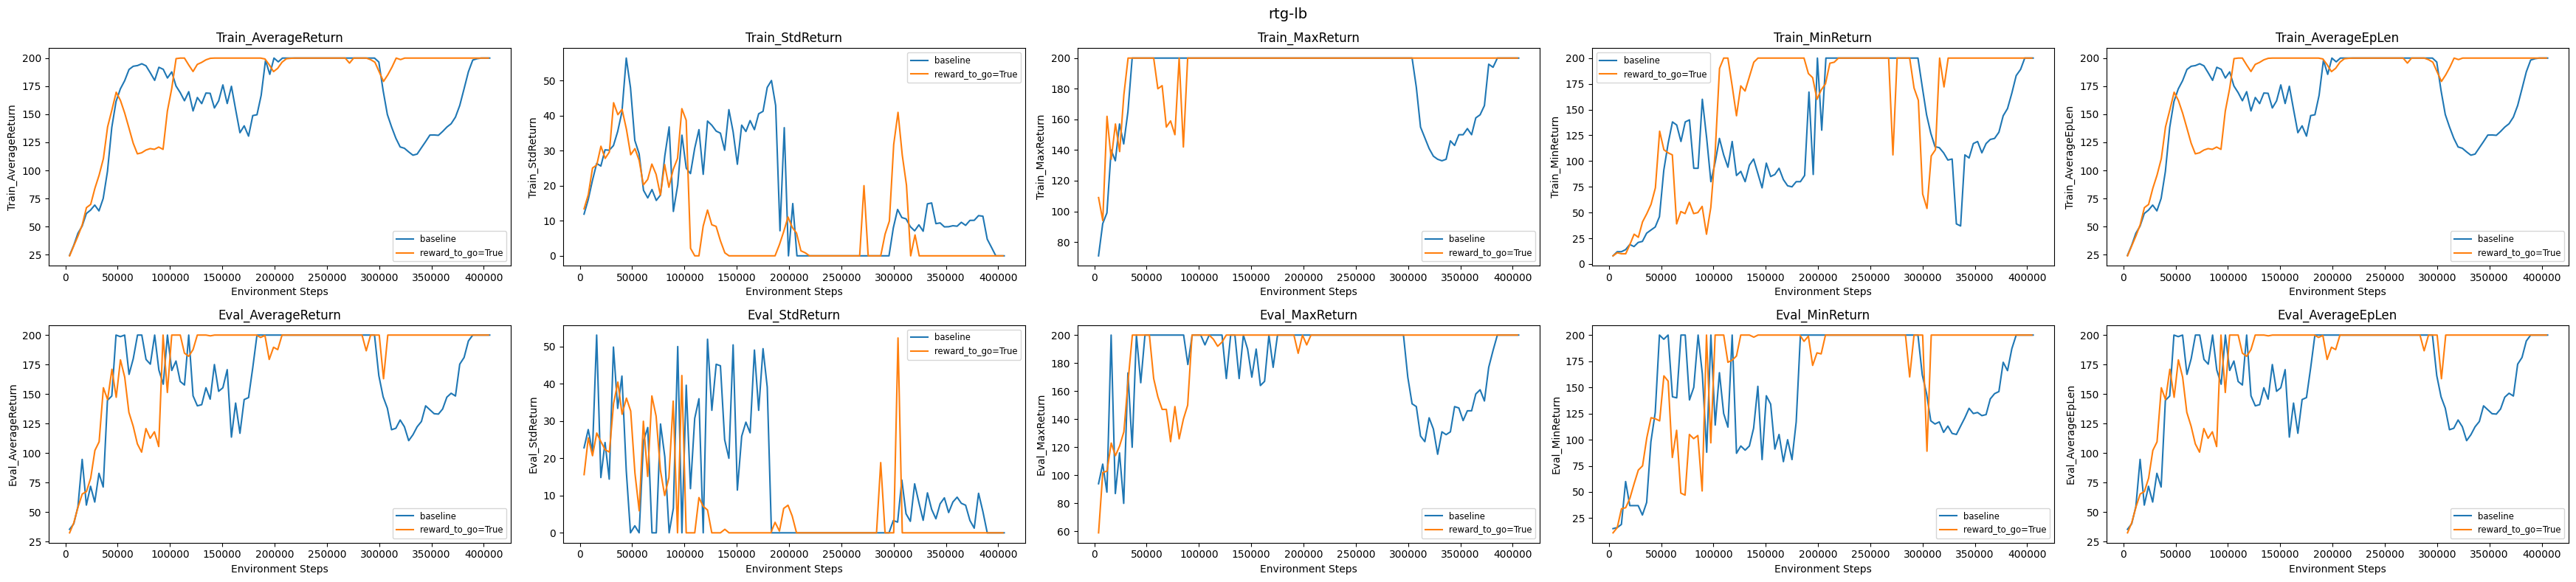

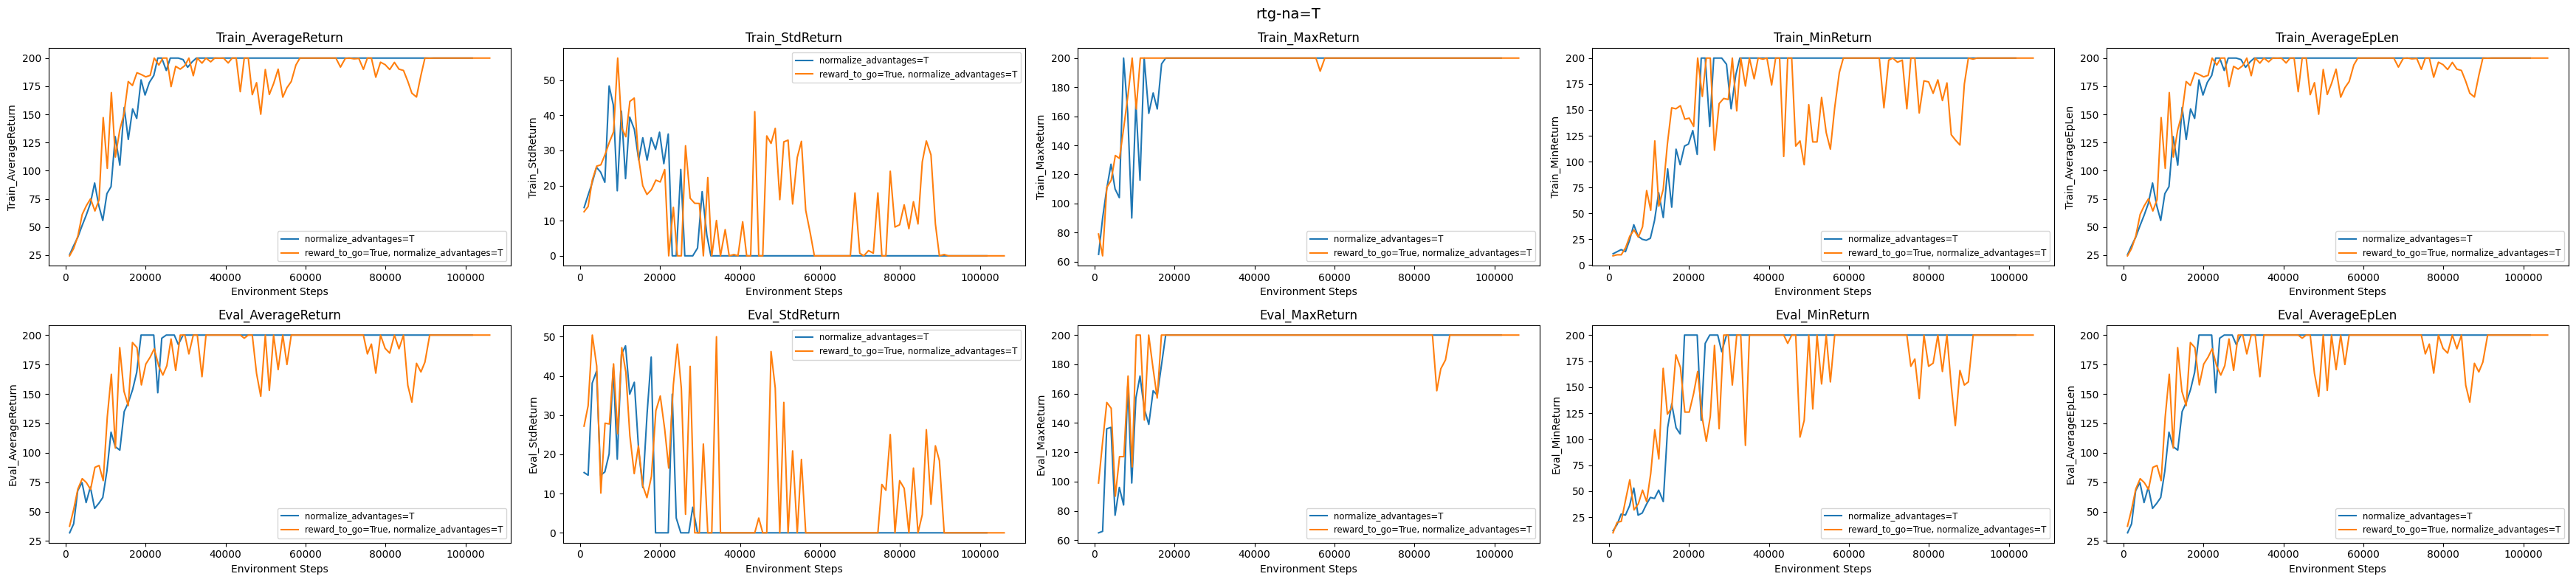

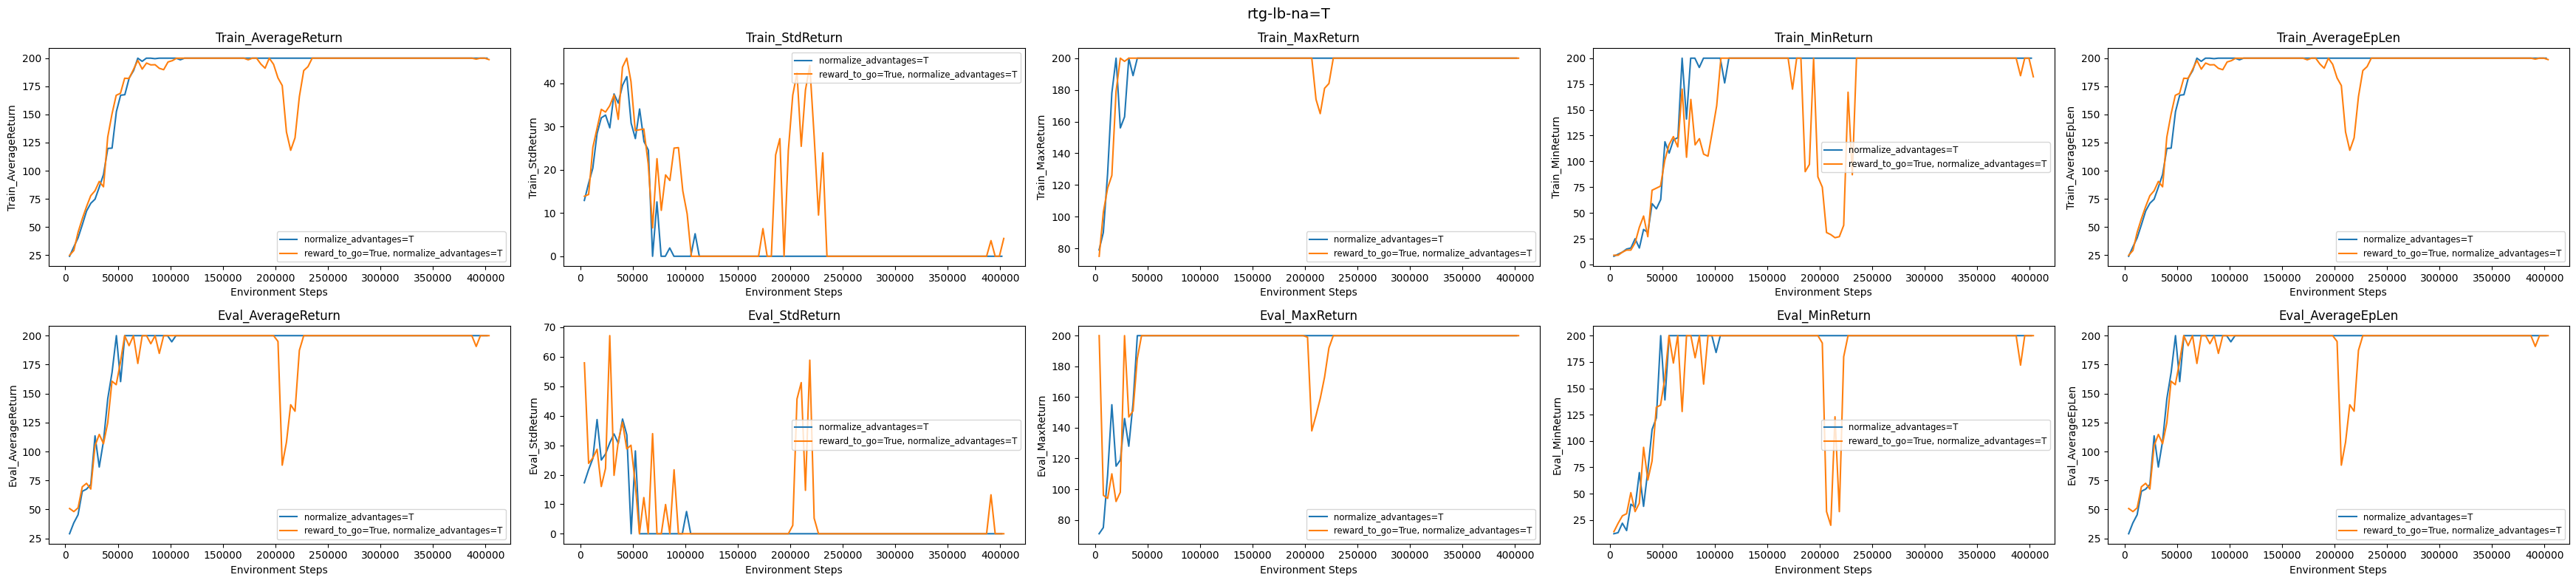

In [9]:
exp_dict = {
    "small_batch": ["cartpole", "cartpole_rtg", "cartpole_na", "cartpole_rtg_na"],
    "large_batch": ["cartpole_lb", "cartpole_lb_rtg", "cartpole_lb_na", "cartpole_lb_rtg_na"],
    "rtg": ["cartpole", "cartpole_rtg"],
    "rtg-lb": ["cartpole_lb", "cartpole_lb_rtg"],
    "rtg-na=T": ["cartpole_na", "cartpole_rtg_na"],
    "rtg-lb-na=T": ["cartpole_lb_na", "cartpole_lb_rtg_na"],
}

color_map = build_color_map(exp_dict["small_batch"] + exp_dict["large_batch"])

#save_dir = Path("/Users/jasonkrone/Developer/homework_spring2026/writeup/plots/hw2")

for title, exp_names in exp_dict.items():
    runs = group_runs(run_data, exp_names)
    if "batch" in title:
        make_plot(runs, title, color_map=color_map)
    else:
        make_plot(runs, title)